# Fragment Descriptors (2D + Optional 3D)

## Estimated Time

- **2D Section (Basics):** ~20 minutes
- **3D Section (Optional):** ~40 minutes
- **Total with 3D:** ~60 minutes
- *Category: Medium to Long*

## Overview

This tutorial teaches you how to calculate and use molecular descriptors for fragments. You'll learn:

- **2D descriptors** (basics): Fast RDKit descriptors computed from molecular structure
- **3D descriptors** (optional): Conformation-dependent descriptors for stereochemistry
- **Combining features**: Merge descriptors with learned GAE embeddings

## Prerequisites

- [x] GSGE installed (see [Installation Guide](../../../Installation.md))
- [ ] Vocabulary available (build your own or load pre-trained)
- [ ] Completed: None (independent module)

## Learning Objectives

By the end of this tutorial, you will be able to:
- Access pre-computed 2D RDKit descriptors
- Calculate custom 2D and 3D descriptors for fragments
- Visualize descriptor distributions
- Combine descriptors with GAE embeddings
- Use combined features for downstream ML tasks

## Table of Contents

### Part 1: 2D Descriptors (Basics) - Required
1. [Load Pre-trained GSGE with 2D Descriptors](#part1-load)
2. [Explore Pre-computed Descriptors](#part1-explore)
3. [Visualize Descriptor Distributions](#part1-visualize)
4. [Compare: Descriptors vs GAE Embeddings](#part1-compare)

---

### Part 2: 3D Descriptors (Optional) - Advanced

**SKIP this part if you:**
- Don't need conformation-dependent features
- Are running on slow hardware
- Don't have `mordred` installed

**Continue if you:**
- Need stereochemistry-dependent descriptors
- Have time for additional computation (~15-30 minutes)
- Want to learn custom descriptor calculation

5. [Check 3D Descriptor Prerequisites](#part2-check)
6. [Define Custom Descriptor Functions](#part2-define)
7. [Calculate Custom Descriptors](#part2-calculate)

---

### Part 3: Combining Features - Required
8. [Concatenate Descriptors + Embeddings](#part3-combine)
9. [Visualize Combined Feature Space](#part3-visualize)
10. [Save and Use Combined Features](#part3-save)

---

# Part 1: 2D Descriptors (Basics)

This section uses pre-computed 2D RDKit descriptors. These are fast to compute and sufficient for most ML tasks.

## 1. Load Pre-trained GSGE with 2D Descriptors

The pre-trained GSGE object includes 45 RDKit descriptors already computed for each fragment.

In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

from GSGE import GSGE, get_tests_dir

# Load pre-trained GSGE with descriptors
tests_dir = get_tests_dir()
if tests_dir is None:
    raise RuntimeError(
        "Cannot find tests directory. This notebook requires running from "
        "a source checkout with the tests/ directory available."
    )

pkl_path = tests_dir / 'test_gsge_save_with_descriptors.pkl'
if not pkl_path.exists():
    raise FileNotFoundError(
        f"Test data file not found: {pkl_path}\n"
        "Please ensure the tests directory has the required test fixtures."
    )

gsge = GSGE(GSGE_load_path=str(pkl_path))

print("[OK] GSGE loaded with pre-computed descriptors")
print(f"  - Number of fragments: {len(gsge.get_fragments_smiles())}")

Data loaded and restored into gsge from C:\Users\Admin\OneDrive - Universiteit Leiden\PhD\Repos\jasper\gsge\tests\test_gsge_save_with_descriptors.pkl
[OK] GSGE loaded with pre-computed descriptors
  - Number of fragments: 185


## 2. Explore Pre-computed Descriptors

The GSGE object provides several methods to access descriptors and embeddings:

In [2]:
# Get fragment descriptors (normalized 2D RDKit descriptors)
descriptors = gsge.get_fragment_descriptors()
print(f"Descriptor matrix shape: {descriptors.shape}")
print(f"  (num_fragments, num_descriptors)")

# Get GAE embeddings (learned graph neural network embeddings)
embeddings = gsge.get_fragment_embeddings()
print(f"\nEmbedding matrix shape: {embeddings.shape}")
print(f"  (num_fragments, embedding_dim)")

# Get descriptor names
descriptor_names = gsge.get_fragment_descriptors_names()
print(f"\nNumber of descriptors: {len(descriptor_names)}")
print(f"First 10 descriptors: {descriptor_names[:10]}")

# Get combined features (embeddings + descriptors)
combined = gsge.get_fragment_descriptors_and_embeddings()
print(f"\nCombined matrix shape: {combined.shape}")
print(f"  (num_fragments, embedding_dim + num_descriptors)")

# Get fragment SMILES
fragment_smiles = gsge.get_fragments_smiles()
print(f"\nExample fragment SMILES:")
for smi in fragment_smiles[:5]:
    print(f"  - {smi}")

Descriptor matrix shape: torch.Size([185, 47])
  (num_fragments, num_descriptors)

Embedding matrix shape: torch.Size([185, 128])
  (num_fragments, embedding_dim)

Number of descriptors: 47
First 10 descriptors: ['MaxEStateIndex', 'MinEStateIndex', 'MolWt', 'NumValenceElectrons', 'FpDensityMorgan1', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n']

Combined matrix shape: torch.Size([185, 175])
  (num_fragments, embedding_dim + num_descriptors)

Example fragment SMILES:
  - O(*1)*1
  - N1=C(*1)N(*1)C(*1)=C1*1
  - N1=C(*1)NC(*1)=C1*1
  - C1=C(*1)N=NN1*1
  - N1=NC(*1)=C(*1)N1


## 3. Visualize Descriptor Distributions

Understanding descriptor distributions helps identify:
- Skewed features (may need log transform)
- Zero-variance features (can be removed)
- Outliers (may need clipping or robust scaling)

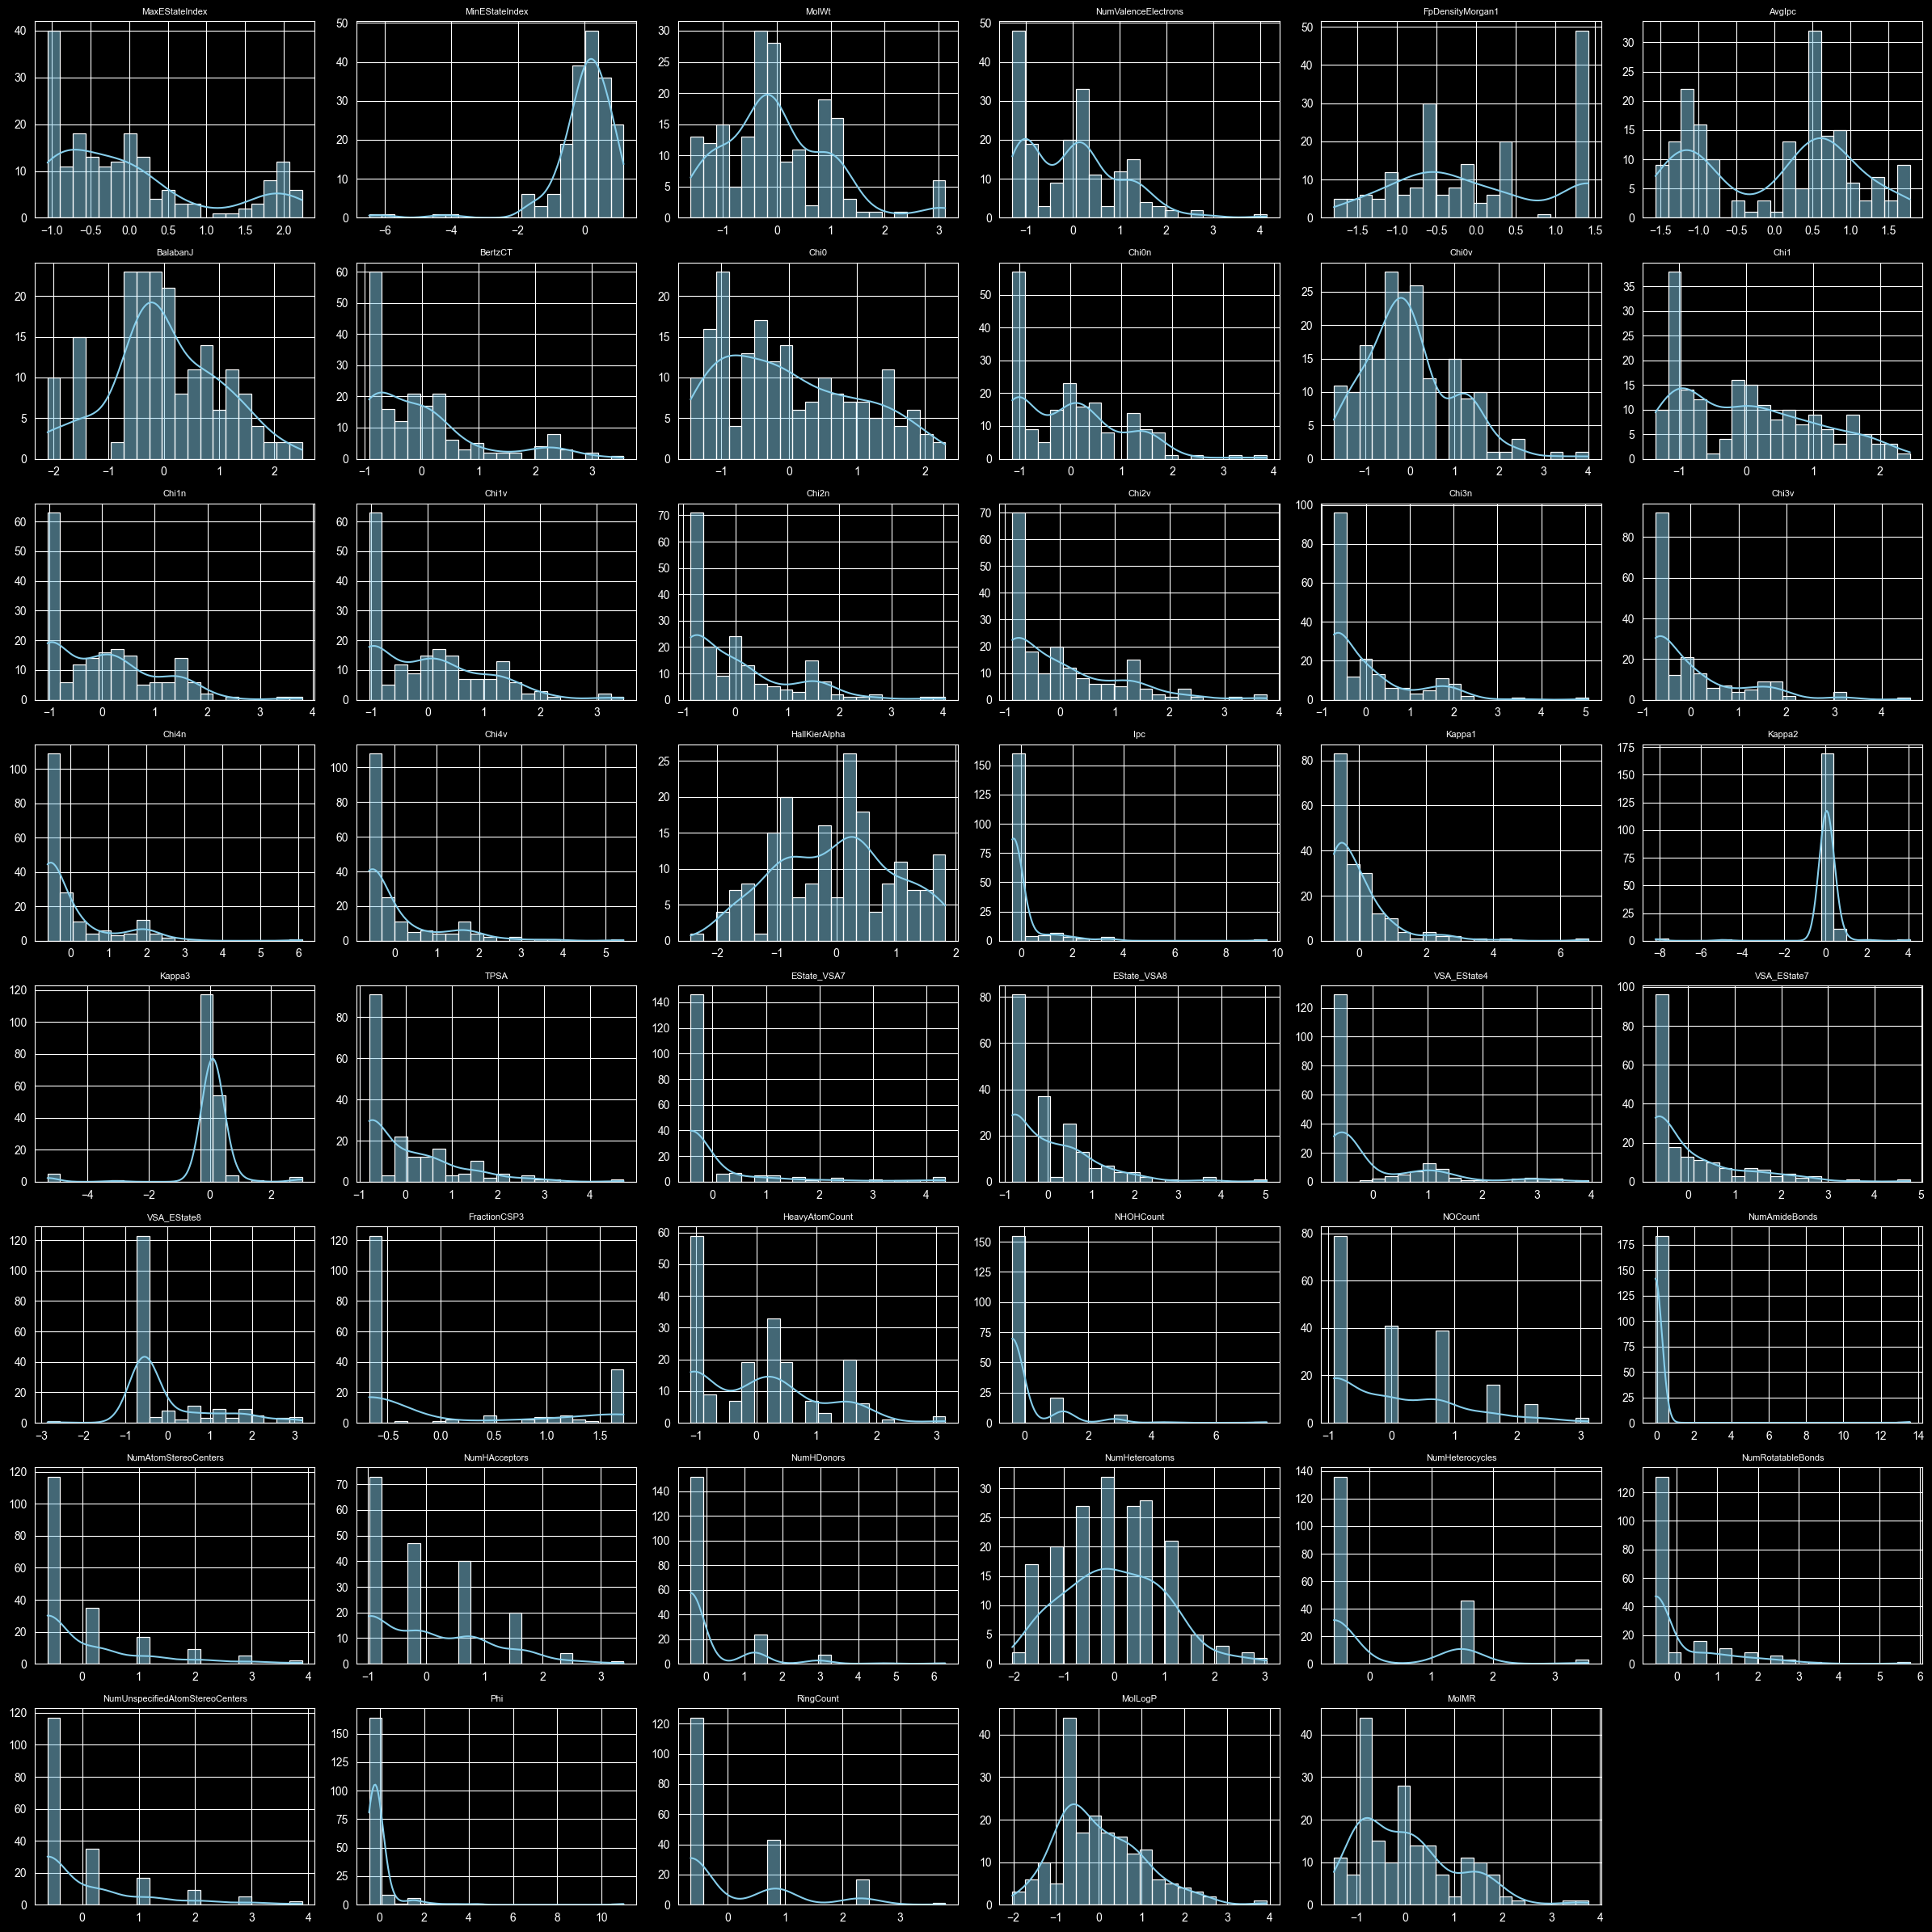

[OK] Plotted distributions for 47 descriptors


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
num_descriptors = descriptors.shape[1]
n_cols = 6
n_rows = int(np.ceil(num_descriptors / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

# Plot each descriptor distribution
for i in range(num_descriptors):
    ax = axes[i]
    sns.histplot(descriptors[:, i].detach().cpu().numpy(), kde=True, ax=ax, 
                 bins=20, color="skyblue")
    ax.set_title(descriptor_names[i], fontsize=8)
    ax.set_ylabel('')
    ax.set_xlabel('')

# Turn off unused subplots
for i in range(num_descriptors, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print(f"[OK] Plotted distributions for {num_descriptors} descriptors")

## 4. Compare: Descriptors vs GAE Embeddings

Use t-SNE to visualize the structure learned by:
- **Hand-crafted descriptors**: Human-designed chemical properties
- **GAE embeddings**: Learned representations from graph neural networks

This helps understand if the learned embeddings capture similar chemical intuition.

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import plotly.express as px

# Convert to numpy arrays explicitly
desc_array = descriptors.detach().cpu().numpy()
emb_array = embeddings.detach().cpu().numpy()

# 1. t-SNE of 2D Descriptors
print("Computing t-SNE for 2D descriptors...")
scaler = StandardScaler()
desc_normalized = scaler.fit_transform(desc_array)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
desc_tsne = tsne.fit_transform(desc_normalized)

df_plot = pd.DataFrame(desc_tsne, columns=['x', 'y'])
df_plot['SMILES'] = fragment_smiles

fig = px.scatter(df_plot, x='x', y='y', hover_name='SMILES',
                 title='t-SNE of 2D RDKit Descriptors (45 features)',
                 width=900, height=700)
fig.show()

Computing t-SNE for 2D descriptors...


In [5]:
# 2. t-SNE of GAE Learned Embeddings
print("Computing t-SNE for GAE embeddings...")
emb_normalized = scaler.fit_transform(emb_array)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(emb_normalized)

df_plot = pd.DataFrame(emb_tsne, columns=['x', 'y'])
df_plot['SMILES'] = fragment_smiles

fig = px.scatter(df_plot, x='x', y='y', hover_name='SMILES',
                 title='t-SNE of GAE Learned Embeddings (Graph Neural Network)',
                 width=900, height=700)
fig.show()

Computing t-SNE for GAE embeddings...


In [6]:
# 3. Color by a specific descriptor to see chemical patterns
print("Coloring embeddings by MolLogP (hydrophobicity)...")

# Find MolLogP descriptor index
if 'MolLogP' in descriptor_names:
    logp_idx = descriptor_names.index('MolLogP')
    logp_values = desc_array[:, logp_idx]
    
    df_plot = pd.DataFrame(emb_tsne, columns=['x', 'y'])
    df_plot['SMILES'] = fragment_smiles
    df_plot['MolLogP'] = logp_values.tolist()
    
    fig = px.scatter(df_plot, x='x', y='y', hover_name='SMILES', color='MolLogP',
                     color_continuous_scale='Viridis',
                     title='t-SNE of GAE Embeddings Colored by MolLogP',
                     width=900, height=700)
    fig.show()
else:
    print("MolLogP not found in descriptor names")

Coloring embeddings by MolLogP (hydrophobicity)...


### Part 1 Summary

**You learned:**
- [OK] How to load pre-trained GSGE with 2D descriptors
- [OK] How to access descriptor and embedding matrices
- [OK] How to visualize descriptor distributions
- [OK] How to compare learned embeddings vs hand-crafted descriptors

**Key Takeaway:** GAE embeddings learn representations that capture chemical similarity, but may not directly encode human-interpretable properties like MolLogP. Combining both gives you the best of both worlds.

---

# Part 2: 3D Descriptors (Optional)

---
**SKIP THIS PART** if you:
- Only need 2D descriptors (sufficient for most tasks)
- Are running on slow hardware
- Don't have `mordred` installed

**Continue if you:**
- Need 3D conformation-dependent descriptors
- Are studying stereochemistry-dependent properties
- Have time for additional computation (~15-30 minutes)

---

3D descriptors require:
1. **Conformation generation**: Computing 3D coordinates for each fragment
2. **Additional package**: `mordred` for 3D descriptor calculation

This section teaches you how to define custom descriptor functions and compute them for fragments.

## 5. Check 3D Descriptor Prerequisites

3D descriptors require the `mordred` package. If not installed, 3D descriptors will return 0.0.

In [7]:
# Check if mordred is available for 3D descriptors
try:
    import mordred
    print("[OK] mordred is installed - 3D descriptors will be calculated")
    mordred_available = True
except ImportError:
    print("[!] mordred is NOT installed - 3D descriptors will return 0.0")
    print("  To install: pip install mordred")
    mordred_available = False

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

print(f"\n3D descriptors available: {mordred_available}")

[!] mordred is NOT installed - 3D descriptors will return 0.0
  To install: pip install mordred

3D descriptors available: False


## 6. Define Custom Descriptor Functions

These functions demonstrate how to calculate custom descriptors for fragments. Key points:

- **Wildcard handling**: Fragments have attachment points (`*`) that need capping
- **3D generation**: Fragments need 3D coordinates before computing 3D descriptors
- **Error handling**: Gracefully handle fragments that fail 3D generation

In [8]:
# --- Wildcard replacement for fragments ---
def cap_wildcards(smiles, cap=''):
    """Replace wildcard attachment points in fragment SMILES."""
    return smiles.replace('(*1)', cap).replace('(*)', cap).replace('*1', cap).replace('*', cap)

# --- Generate 3D molecule with hydrogens ---
def smiles_to_3d_mol(smiles, max_attempts=1000000, ff='UFF'):
    """Generate a 3D conformation for a molecule from SMILES."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        mol = Chem.AddHs(mol)
        success = AllChem.EmbedMolecule(
            mol,
            useMacrocycleTorsions=True,
            maxAttempts=max_attempts
        )
        if success != 0:
            return None
        if ff == 'UFF':
            AllChem.UFFOptimizeMolecule(mol)
        return mol
    except:
        return None

# --- 3D Mordred descriptor functions ---
def get_vsa_estate9(smiles):
    """Get VSA_EState9 descriptor (requires mordred package)."""
    if not mordred_available:
        return 0.0
    try:
        smiles = cap_wildcards(smiles)
        mol = smiles_to_3d_mol(smiles)
        if mol is None:
            return 0.0
        from mordred import Calculator, descriptors
        calc = Calculator(descriptors, ignore_3D=False)
        result = calc(mol)
        if hasattr(result, 'VSA_EState9'):
            val = result.VSA_EState9
            return float(val) if isinstance(val, (int, float)) else 0.0
        return 0.0
    except Exception:
        return 0.0

def get_fnsa4(smiles):
    """Get FNSA4 descriptor (requires mordred package)."""
    if not mordred_available:
        return 0.0
    try:
        smiles = cap_wildcards(smiles)
        mol = smiles_to_3d_mol(smiles)
        if mol is None:
            return 0.0
        from mordred import Calculator, descriptors
        calc = Calculator(descriptors, ignore_3D=False)
        result = calc(mol)
        if hasattr(result, 'FNSA4'):
            val = result.FNSA4
            return float(val) if isinstance(val, (int, float)) else 0.0
        return 0.0
    except Exception:
        return 0.0

# --- 2D RDKit descriptor functions ---
def get_mollogp(smiles):
    """Get LogP (partition coefficient) descriptor from RDKit."""
    try:
        smiles = cap_wildcards(smiles, cap='')
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return 0.0
        value = Descriptors.MolLogP(mol)
        return float(value) if isinstance(value, (int, float)) else 0.0
    except Exception:
        return 0.0

def get_fr_al_oh(smiles):
    """Get Al-OH fragment count descriptor from RDKit."""
    try:
        smiles = cap_wildcards(smiles, cap='')
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return 0.0
        value = Descriptors.fr_Al_OH(mol)
        return float(value) if isinstance(value, (int, float)) else 0.0
    except Exception:
        return 0.0

print("[OK] Custom descriptor functions defined")
print(f"  - 3D descriptors: {'enabled' if mordred_available else 'disabled (mordred not installed)'}")
print(f"  - 2D descriptors: enabled")

[OK] Custom descriptor functions defined
  - 3D descriptors: disabled (mordred not installed)
  - 2D descriptors: enabled


## 7. Calculate Custom Descriptors

Now use the custom descriptor functions to calculate descriptors for all fragments.

In [9]:
# Define descriptor functions and names
desc_fns = [get_vsa_estate9, get_fnsa4, get_mollogp, get_fr_al_oh]
desc_names = ['vsa_estate9', 'fnsa4', 'mollogp', 'fr_al_oh']

# Calculate descriptors for all fragments
descriptor_calc_fns_list = list(zip(desc_names, desc_fns))
descriptor_keys = desc_names

print("Calculating custom descriptors...")
gsge.calc_fragment_descriptors(
    descriptor_calc_fns_list=descriptor_calc_fns_list,
    descriptor_keys=descriptor_keys,
    smiles_input=True
)

print(f"[OK] Custom descriptors calculated")
print(f"  - Descriptor names: {descriptor_names}")

# View the calculated descriptors
custom_descriptors = gsge.get_fragment_descriptors()
print(f"\nCustom descriptor matrix shape: {custom_descriptors.shape}")
print(f"  (num_fragments, num_custom_descriptors)")

Calculating custom descriptors...
[OK] Custom descriptors calculated
  - Descriptor names: ['MaxEStateIndex', 'MinEStateIndex', 'MolWt', 'NumValenceElectrons', 'FpDensityMorgan1', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'TPSA', 'EState_VSA7', 'EState_VSA8', 'VSA_EState4', 'VSA_EState7', 'VSA_EState8', 'FractionCSP3', 'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumAmideBonds', 'NumAtomStereoCenters', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumHeterocycles', 'NumRotatableBonds', 'NumUnspecifiedAtomStereoCenters', 'Phi', 'RingCount', 'MolLogP', 'MolMR']

Custom descriptor matrix shape: torch.Size([185, 2])
  (num_fragments, num_custom_descriptors)


### Part 2 Summary

**You learned:**
- [OK] How to define custom descriptor functions
- [OK] How to handle wildcards in fragment SMILES
- [OK] How to generate 3D conformations
- [OK] How to calculate custom descriptors for all fragments

**Key Takeaway:** Custom descriptors allow you to incorporate domain-specific knowledge, but 3D descriptors are computationally expensive and may not always improve performance.

---

# Part 3: Combining Features

This section shows how to combine descriptors with GAE embeddings for enhanced features.

## 8. Concatenate Descriptors + Embeddings

Combining features gives you:
- **Learned representations**: GAE embeddings capture structural patterns
- **Human interpretable features**: Descriptors encode chemical properties

This often improves ML model performance.

In [10]:
# Get combined features (already implemented in GSGE)
combined_features = gsge.get_fragment_descriptors_and_embeddings()

print(f"Combined feature matrix shape: {combined_features.shape}")
print(f"  - Embedding dim: {embeddings.shape[1]}")
print(f"  - Descriptor dim: {custom_descriptors.shape[1]}")
print(f"  - Combined dim: {combined_features.shape[1]}")

# Verify concatenation
expected_dim = embeddings.shape[1] + custom_descriptors.shape[1]
assert combined_features.shape[1] == expected_dim, "Feature dimension mismatch!"
print(f"\n[OK] Feature dimensions match: {embeddings.shape[1]} + {custom_descriptors.shape[1]} = {expected_dim}")

Combined feature matrix shape: torch.Size([185, 130])
  - Embedding dim: 128
  - Descriptor dim: 2
  - Combined dim: 130

[OK] Feature dimensions match: 128 + 2 = 130


## 9. Visualize Combined Feature Space

Visualize the combined descriptor + embedding space to see how features cluster.

In [11]:
# t-SNE of combined features
print("Computing t-SNE for combined features...")

combined_array = combined_features.detach().cpu().numpy()
combined_normalized = scaler.fit_transform(combined_array)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
combined_tsne = tsne.fit_transform(combined_normalized)

df_plot = pd.DataFrame(combined_tsne, columns=['x', 'y'])
df_plot['SMILES'] = fragment_smiles

fig = px.scatter(df_plot, x='x', y='y', hover_name='SMILES',
                 title='t-SNE of Combined Features (Descriptors + GAE Embeddings)',
                 width=900, height=700)
fig.show()

Computing t-SNE for combined features...


## 10. Save and Use Combined Features

Save the GSGE object with custom descriptors for later use in ML models.

In [12]:
from pathlib import Path

# Save relative to notebook directory
output_dir = Path.cwd()
output_path = output_dir / 'gsge_with_custom_descriptors.pkl'
gsge.save_gsge_data(str(output_path))

print(f"[OK] GSGE saved to: {output_path}")
print(f"  - Includes {embeddings.shape[1]}D GAE embeddings")
print(f"  - Includes {custom_descriptors.shape[1]}D custom descriptors")
print(f"  - Total: {combined_features.shape[1]}D features")

Data saved to C:\Users\Admin\OneDrive - Universiteit Leiden\PhD\Repos\jasper\gsge\use_examples\05_mol_frag_features\gsge_with_custom_descriptors.pkl
[OK] GSGE saved to: C:\Users\Admin\OneDrive - Universiteit Leiden\PhD\Repos\jasper\gsge\use_examples\05_mol_frag_features\gsge_with_custom_descriptors.pkl
  - Includes 128D GAE embeddings
  - Includes 2D custom descriptors
  - Total: 130D features


### Example: Using Combined Features in ML

Here's how to use the combined features for a downstream ML task:

In [13]:
import torch

# Example: Get features for a specific fragment
fragment_id = 0

# Get individual components
frag_embedding = embeddings[fragment_id]  # GAE embedding
frag_descriptors = custom_descriptors[fragment_id]  # Custom descriptors
frag_combined = combined_features[fragment_id]  # Combined

print(f"Fragment {fragment_id} ({fragment_smiles[fragment_id]}):")
print(f"  - Embedding: {frag_embedding[:3].numpy()}... (dim: {len(frag_embedding)})")
print(f"  - Descriptors: {frag_descriptors.numpy()} (dim: {len(frag_descriptors)})")
print(f"  - Combined: {frag_combined[:3].numpy()}... (dim: {len(frag_combined)})")

# Example: Use in a PyTorch model
class SimplePredictor(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

# Create model with combined feature dimension
model = SimplePredictor(combined_features.shape[1])
print(f"\n[OK] Example model created with input dim: {combined_features.shape[1]}")

Fragment 0 (O(*1)*1):
  - Embedding: [ 0.8299782   0.73504984 -1.2344574 ]... (dim: 128)
  - Descriptors: [-1.2334139  -0.18308337] (dim: 2)
  - Combined: [ 0.8299782   0.73504984 -1.2344574 ]... (dim: 130)

[OK] Example model created with input dim: 130


---

## Summary

### What You Accomplished

**Part 1: 2D Descriptors (Basics)**
- [OK] Loaded pre-trained GSGE with 45 RDKit descriptors
- [OK] Explored descriptor and embedding matrices
- [OK] Visualized descriptor distributions
- [OK] Compared learned embeddings vs hand-crafted descriptors

**Part 2: 3D Descriptors (Optional)**
- [OK] Defined custom descriptor functions
- [OK] Handled wildcards and 3D conformation generation
- [OK] Calculated custom 2D and 3D descriptors

**Part 3: Combining Features**
- [OK] Concatenated descriptors with GAE embeddings
- [OK] Visualized combined feature space
- [OK] Saved GSGE with custom descriptors
- [OK] Saw example ML usage

### Key Takeaways

1. **2D descriptors** are fast and sufficient for most tasks
2. **3D descriptors** add conformational information but are expensive
3. **GAE embeddings** learn structural patterns from data
4. **Combined features** often give the best ML performance

### Next Steps

- [End-to-End Property Prediction](../06_end_to_end/README.md) - Use descriptors in a full ML pipeline
- [GAE Training](../03_GAE/README.md) - Train your own graph autoencoder
- [Using Embeddings](../04_use_embeddings/README.md) - More embedding applications

---

**Questions?** Open an issue on [GitHub](https://github.com/CDDLeiden/GSGE/issues)